In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("IPL 2022.csv")

In [3]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [5]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


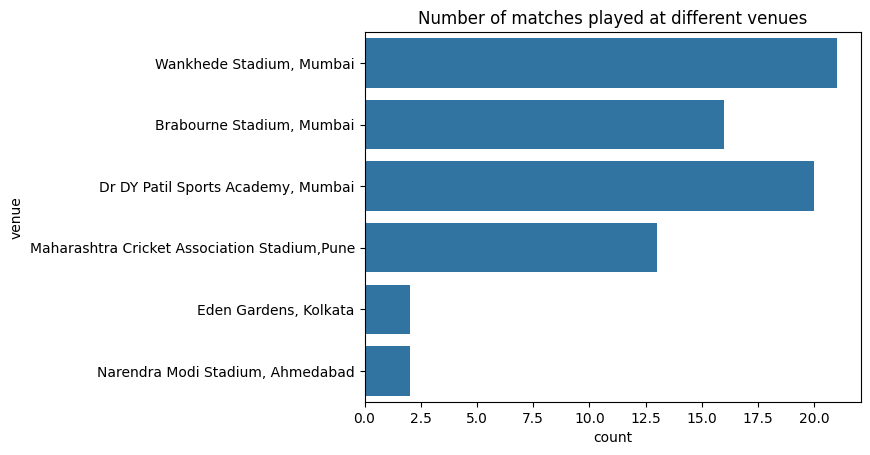

In [6]:
sns.countplot(y= df["venue"])
plt.title("Number of matches played at different venues")
plt.show()

In [7]:
team1_counts = df["team1"].value_counts()
team2_counts = df["team2"].value_counts()
match_counts = team1_counts.add(team2_counts, fill_value=0)
print(match_counts)

Banglore     16.0
Chennai      14.0
Delhi        14.0
Gujarat      16.0
Hyderabad    14.0
Kolkata      14.0
Lucknow      15.0
Mumbai       14.0
Punjab       14.0
Rajasthan    17.0
Name: count, dtype: float64


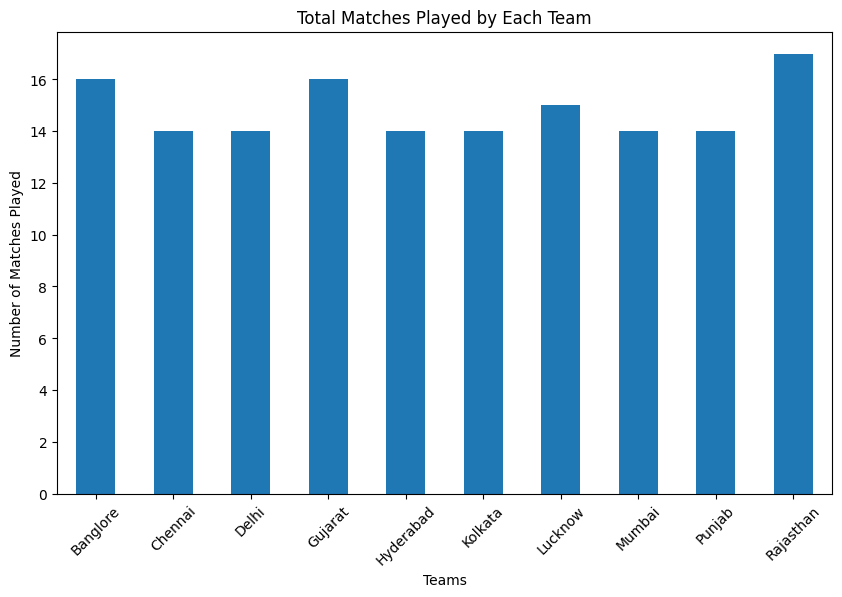

In [8]:
plt.figure(figsize=(10,6))
match_counts.plot(kind='bar')
plt.xlabel("Teams")
plt.ylabel("Number of Matches Played")
plt.title("Total Matches Played by Each Team")
plt.xticks(rotation=45)
plt.show()

In [9]:
matches_won =df["match_winner"].value_counts()
print(matches_won)

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64


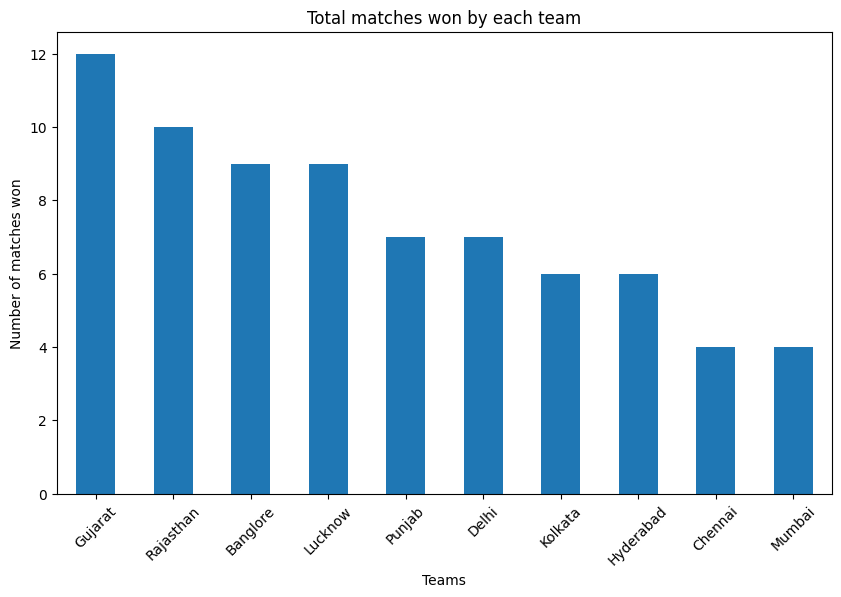

In [10]:
plt.figure(figsize=(10,6))
matches_won.plot(kind="bar")
plt.xlabel("Teams")
plt.ylabel("Number of matches won")
plt.title("Total matches won by each team")
plt.xticks(rotation=45)
plt.show()

In [53]:
man_of_match = df['player_of_the_match'].value_counts().head()
man_of_match

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Wanindu Hasaranga    2
Umesh Yadav          2
Quinton de Kock      2
Name: count, dtype: int64

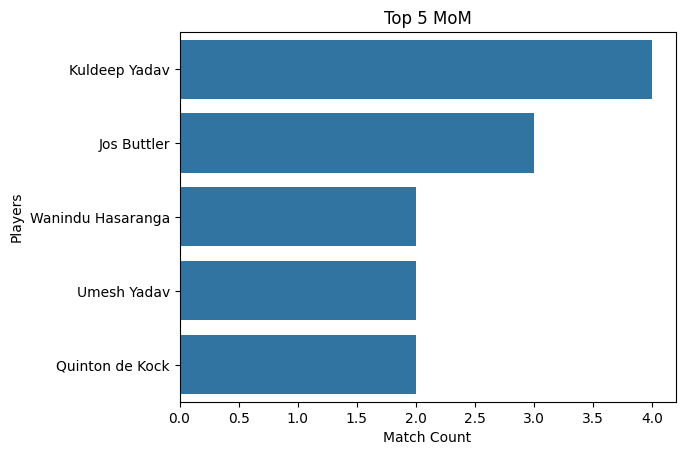

In [12]:
sns.barplot(
    x=man_of_match.values,
    y=man_of_match.index,
)

plt.title("Top 5 MoM")
plt.xlabel("Match Count")
plt.ylabel("Players")
plt.show()

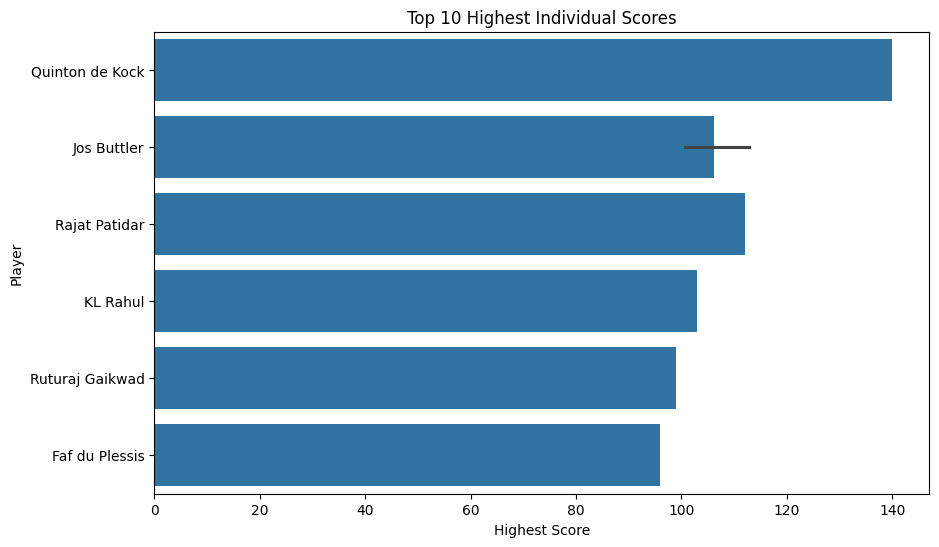

In [44]:
top_score = df.sort_values(by='highscore', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_score, x='highscore', y='top_scorer')
plt.xlabel("Highest Score")
plt.ylabel("Player")
plt.title("Top 10 Highest Individual Scores")
plt.show()

In [13]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(10)
high

top_scorer
Jos Buttler         651
Quinton de Kock     377
KL Rahul            351
Shubman Gill        288
Faf du Plessis      257
Liam Livingstone    239
David Warner        213
W. Saha             190
Ishan Kishan        180
Shikhar Dhawan      158
Name: highscore, dtype: int64

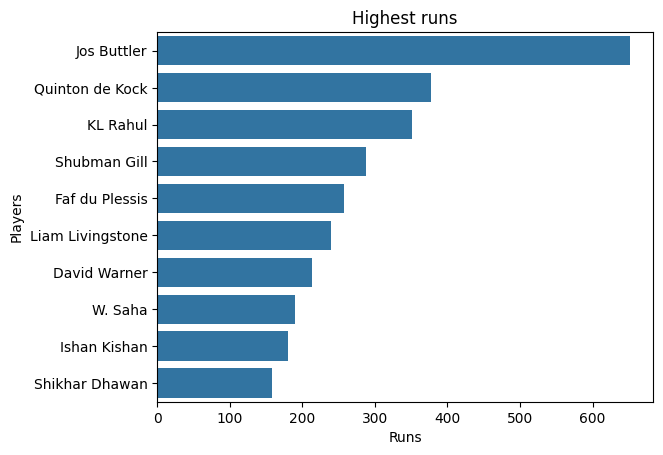

In [14]:
sns.barplot(x=high.values, y=high.index)
plt.xlabel("Runs")
plt.ylabel("Players")
plt.title("Highest runs")
plt.show()

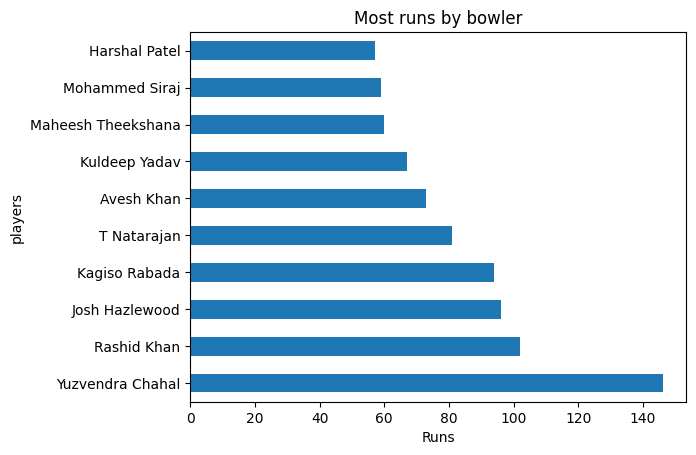

In [15]:
df['most_runs'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[1])
df['most_runs'] = df['most_runs'].astype(int)
most_runs_bowlers = df.groupby('best_bowling')['most_runs'].sum().sort_values(ascending=False).head(10)
most_runs_bowlers.plot(kind = 'barh')
plt.xlabel("Runs")
plt.ylabel("players")
plt.title("Most runs by bowler")
plt.show()

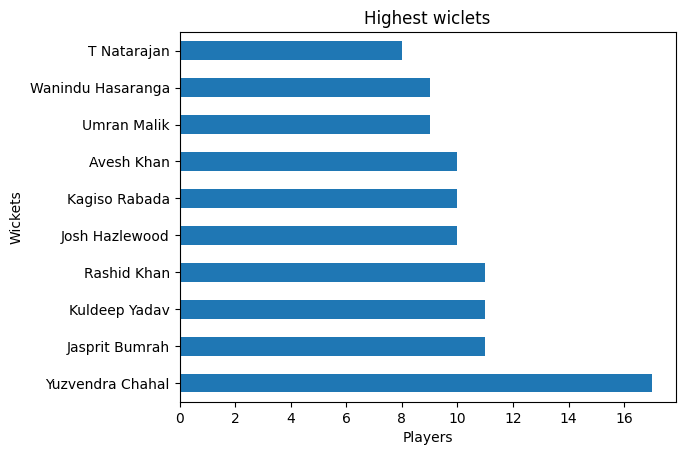

In [51]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')
plt.xlabel("Players")
plt.ylabel("Wickets")
plt.title("Highest wiclets")
plt.show()


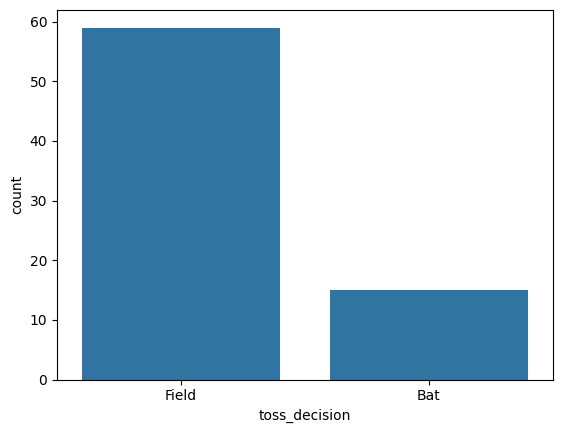

In [18]:
sns.countplot(x =df["toss_decision"])
plt.show()

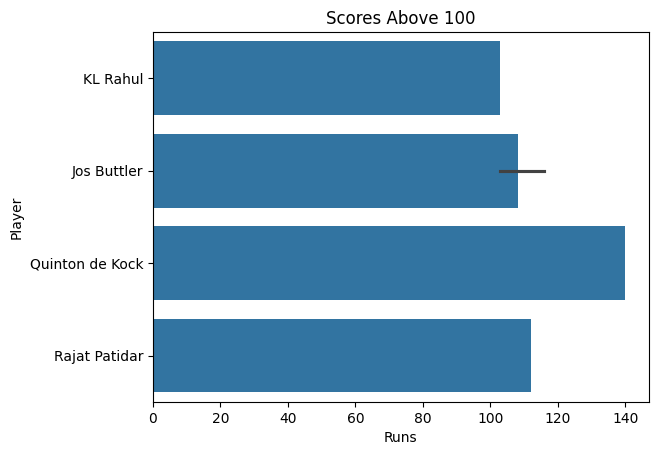

In [50]:
centuries = df[df["highscore"]> 100]
sns.barplot(data=centuries, y="top_scorer", x= "highscore")
plt.xlabel("Runs")
plt.ylabel("Player")
plt.title("Scores Above 100")
plt.show()